# TIPTOP residual PSDs and spatial-frequency sampling

**The simulation defines the spatial grid; the spatial grid defines the Fourier grid; TIPTOP is configured to evaluate the residual AO PSD on a finer, sufficiently large auxiliary grid; FIATLUX extracts its exact frequency samples.**

FIATLUX owns `N`, `dx`, the physical extent and pupil padding. This notebook never changes an existing simulation grid to accommodate TIPTOP. No PSD interpolation and no fitted RMS normalization are used.

Optional environment: `python -m pip install -e '.[tiptop,tutorials]'` (Python 3.12 tested). The installed TIPTOP package supplies the HARMONI SCAO preset and its assets; no unexplained local files are required. This notebook uses TIPTOP 1.5.1 / P3 1.6.2. Only standard P3 camera configuration is used; no frequency-domain subclass or sampling hook is needed.

Sources: [ORION presets](https://astro-tiptop-services.github.io/astro-tiptop-services/docs/orion/interactivetools/), [P3 frequencyDomain](https://github.com/astro-tiptop/P3/blob/main/p3/aoSystem/frequencyDomain.py), [P3 fourierModel](https://github.com/astro-tiptop/P3/blob/main/p3/aoSystem/fourierModel.py). Equations below describe the pinned installed versions.

In [1]:
from pathlib import Path
import sys
root = Path.cwd() if (Path.cwd() / "fiatlux").exists() else Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import copy, json, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from fiatlux import (Grid, Spectrum, PhotometricBand, Field, FieldDimension,
                     tiptop_psd, load_harmoni_scao_config, TiptopSamplingError)
from fiatlux.optics.tiptop import configure_tiptop_sampling
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
torch.set_num_threads(4)

## 1. What is a spatial PSD?

Let $h(x,y)$ be a stationary random **OPD in metres**. With spatial frequencies in cycles/m, its density $W_h$ satisfies
$$\sigma_h^2=\iint W_h(f_x,f_y)\,df_x\,df_y
\simeq\sum_{ij}W_h(f_i,f_j)\Delta f_x\Delta f_y.$$
Thus $W_h$ has units m²/(cycles/m)², conventionally **m⁴**. A plot in nm² m² uses OPD squared in nm² instead.

Phase at wavelength $\lambda$ is $\phi=2\pi h/\lambda$, hence
$$W_h=(\lambda/2\pi)^2W_\phi.$$
FIATLUX stores **unshifted phase density in rad² m²**. Changing the reference wavelength changes phase, not OPD.

**Important P3 convention:** `powerSpectrumDensity()` returns centered OPD bin powers $B_P$ in nm² after multiplying by $(dk\,\lambda_\mathrm{ref}[\mathrm{nm}]/2\pi)^2$. Here $dk=2k_c/\mathrm{resAO}$, which is not exactly `PSDstep` because of integer rounding. Recover the evaluated continuous density first:
$$W_h(f)=B_P(f)\,10^{-18}/dk^2.$$
Select its exact frequency samples, then integrate with **FIATLUX's** bin area:
$$\sigma_F^2=\sum W_h(f_F)\,\Delta f_F^2.$$
Multiplying selected P3 bin powers directly by neither area, or dividing them by $\Delta f_F^2$, would give the wrong normalization when the grids differ. No empirical RMS factor is used.

## 2. Physical grid → Fourier grid

For $N$ pixels at pitch $\Delta x$: $L=N\Delta x$, $\Delta f=1/L$, and $f_\mathrm{Nyquist}=1/(2\Delta x)$. For even $N$, FFT samples include the negative Nyquist endpoint but not the positive endpoint.

The following cell defines a **standalone example simulation input**, using the supplied HARMONI values. In an existing simulation, use its existing `pupil_grid` directly; do not reconstruct it from the telescope diameter. `D/N` is chosen here only to demonstrate the difficult no-padding case.

In [2]:
D = 38.542  # m, physical telescope diameter
N = 400
pupil_grid = Grid(N, N, D/N, D/N, dtype=torch.float64)
original_grid = copy.deepcopy(pupil_grid.__dict__)
spectrum = Spectrum(magnitude=14, band=PhotometricBand.HCM2, samples=3, dtype=torch.float64)
L = pupil_grid.nx * pupil_grid.dx
df = 1/L
f = torch.fft.fftshift(torch.fft.fftfreq(pupil_grid.nx, d=pupil_grid.dx, dtype=torch.float64))
print(f"N={N}; D={D:.6f} m; L={L:.6f} m; dx={pupil_grid.dx:.9f} m")
print(f"df={df:.12f} cycles/m; Nyquist={1/(2*pupil_grid.dx):.6f} cycles/m")
print("Frequency endpoints and DC [cycles/m]:", f[[0, 1, N//2, -2, -1]].tolist())
print("HCM2 wavelengths [µm]:", (spectrum.wavelengths * 1e6).tolist())

N=400; D=38.542000 m; L=38.542000 m; dx=0.096355000 m
df=0.025945721551 cycles/m; Nyquist=5.189144 cycles/m
Frequency endpoints and DC [cycles/m]: [-5.189144310103264, -5.163198588552747, 0.0, 5.137252867002231, 5.163198588552747]
HCM2 wavelengths [µm]: [1.0750000000000002, 1.1, 1.125]


## 3. FFT-like padded grid versus pupil-only MFT grid

A pupil-only MFT simulation can use support $L=D$ and $\Delta f_F=1/D$. An FFT-like padded support $L=2D$ gives $\Delta f_P=1/(2D)$. FIATLUX's MFT does not require padding just to satisfy P3's internal Fourier sampling.

The following compares two separately defined simulations at fixed pitch. It does **not** replace the input grid. Doubling the extent halves the frequency step without changing the Nyquist frequency. P3 may use the larger grid internally while FIATLUX keeps the pupil-only simulation.

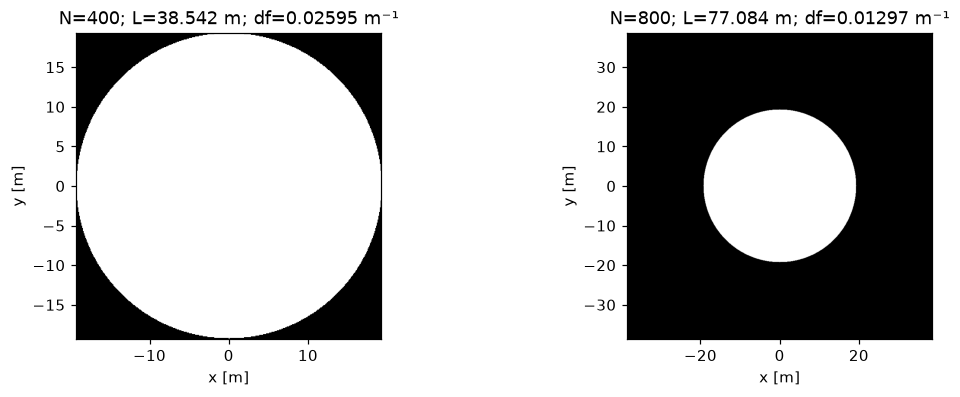

In [3]:
comparison = [pupil_grid, Grid(800, 800, pupil_grid.dx, pupil_grid.dy, dtype=torch.float64)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for ax, grid in zip(axes, comparison):
    x, y = grid.meshgrid()
    pupil = (x*x+y*y <= (D/2)**2).numpy()
    extent = grid.nx*grid.dx
    ax.imshow(pupil, origin="lower", extent=np.array([-1,1,-1,1])*extent/2, cmap="gray")
    ax.set(title=f"N={grid.nx}; L={extent:.3f} m; df={1/extent:.5f} m⁻¹", xlabel="x [m]", ylabel="y [m]")
plt.show()
assert pupil_grid.__dict__ == original_grid

## 4. How P3 constructs its grid

For camera pixel size $p$ in mas and $R=206264806.247$ mas/rad, P3 computes, for each science wavelength,
$$s=\lambda R/(pD),\quad k=\lceil2/s\rceil,\quad \mathrm{samp}=ks,\quad \Delta f_\lambda=p/(\lambda Rk).$$
`PSDstep` is the minimum $\Delta f_\lambda$. With PSD expansion, `kRef_` is the ceiling of $k_i\lambda_i/\lambda_\min$ for the channel that supplies that minimum; `nOtf = FieldOfView * kRef_`. It need not be one. P3's `kx_`, `ky_` are centered coordinates with a numerical $10^{-10}$ cycles/m offset.

The camera configuration obeys `PSDstep ≤ 1/(2D)`. This does **not** make an unpadded FIATLUX grid incompatible: choose a finer auxiliary P3 grid with $q=\Delta f_F/\Delta f_P$ an integer, and enough samples to cover both FIATLUX endpoints.

The adapter searches integer ratios and wavelength-dependent camera regimes; it does not assume $q=2$ or `kRef_=1`. For multiple HCM2 channels, a different integer ratio may be needed. After constructing the real P3 frequency domain, coordinate equality—not the ratio alone—is the authoritative test. No P3 sampling override is used.

In [4]:
config = load_harmoni_scao_config()
physical_overrides = {
    "telescope": {"TelescopeDiameter": D, "ZenithAngle": 52.4},
    "sources_science": {"Wavelength": spectrum.wavelengths.tolist()},
}
example_config = copy.deepcopy(config)
for section, values in physical_overrides.items():
    example_config[section].update(values)
auxiliary_config = configure_tiptop_sampling(pupil_grid, example_config)
print("P3 auxiliary sensor configuration:", auxiliary_config["sensor_science"])
assert pupil_grid.__dict__ == original_grid

Cupy import failed. P3 will fall back to CPU use.


Cupy import failed. MASTSEL will fall back to CPU use.


Cupy import failed. SEEING will fall back to CPU use.


P3 auxiliary sensor configuration: {'PixelScale': 2.0068834607093846, 'FieldOfView': 600}


## 5. Configure P3 to the unchanged FIATLUX target

The physical starting point is TIPTOP's installed **HARMONI SCAO NGS** preset. Only diameter, zenith and HCM2 wavelengths are overridden here. Atmosphere, DM, WFS and loop settings remain inspectable configuration data.

The science magnitude 14 sets FIATLUX source flux. It is **not** converted into WFS photons: that requires a guide-star band, throughput and flux calibration. This example retains the preset's `NumberPhotons`. To change the AO brightness, override that calibrated photons/subaperture/frame value. Static errors are separate from the residual atmospheric/AO PSD. The loop frequency shapes the residual statistics; it does not turn independent draws into a temporal sequence.

In [5]:
result = tiptop_psd(pupil_grid, config=config, overrides=physical_overrides)
assert result.grid is pupil_grid
assert pupil_grid.__dict__ == original_grid
assert result.diagnostics["nOtf"] > pupil_grid.nx
assert result.diagnostics["PSDstep"] < df
np.testing.assert_allclose(result.p3_frequency_x[result.indices_x], f.numpy(), atol=2e-10)
np.testing.assert_allclose(result.p3_frequency_y[result.indices_y], f.numpy(), atol=2e-10)
print(json.dumps(result.diagnostics, indent=2))
print("Atmosphere:", result.config["atmosphere"])
print("WFS photons/subap/frame:", result.config["sensor_HO"]["NumberPhotons"])
print("AO loop [Hz]:", result.config["RTC"]["SensorFrameRate_HO"])
print("P3 camera metadata:", result.config["sensor_science"])
print("All grid and camera quantities are unmodified standard P3 outputs.")

{
  "p3_version": "1.6.2",
  "tiptop_version": "1.5.1",
  "mode": "exact frequency-grid extraction",
  "nOtf": 1200,
  "target_N": 400,
  "PSDstep": 0.008648573850172103,
  "target_df": 0.025945721550516318,
  "k_": [
    1,
    1,
    1
  ],
  "kRef_": 2,
  "samp": [
    2.866666666666668,
    2.933333333333335,
    3.000000000000001
  ],
  "sampling_ratio": 3,
  "selected_index_first": 0,
  "selected_index_last": 1197,
  "rms_nm": [
    143.5451272822788
  ],
  "full_p3_rms_nm": [
    143.98781691494793
  ],
  "p3_normalization_dk": 0.00865650969529086,
  "ao_cutoff_cycles_per_m": 1.3157894736842106,
  "component_sum_matches_total": true
}
Atmosphere: {'Wavelength': 5e-07, 'Seeing': 0.65, 'L0': 25.0, 'Cn2Weights': [0.43840001, 0.14700001, 0.1142, 0.056, 0.03683, 0.0442, 0.0527, 0.0794, 0.01829, 0.012939], 'Cn2Heights': [83.16413254, 243.29187551, 710.47154255, 2735.63637091, 5583.67373605, 8599.18858474, 11598.92106005, 14221.06437269, 17219.02406272, 21912.89106645], 'WindSpeed': [6

The API checks actual `PSDstep`, `nOtf`, `kx_`, `ky_`, coverage and the coordinate values selected by index, before and after PSD calculation.

A **crop** keeps the frequency step unchanged. **Exact frequency-grid extraction** can select a cropped extent and every $q$th existing sample, with indices derived from coordinates. It creates no new density values and averages no neighboring bins. The resulting quadrature need not equal P3's full-grid integral: it uses different frequency samples and the FIATLUX cell area.

### Exact subset example: $1/D$ from $1/(2D)$

For the same unchanged pupil grid, a monochromatic HCM2 reference permits $q=2$. We request this ratio explicitly and inspect actual backend coordinates. The multi-channel calculation above chooses its own compatible integer ratio. These dots show existing frequency samples, not interpolation locations.

Pupil-only FIATLUX: N= 400 df= 0.025945721550516318 cycles/m
Auxiliary P3: nOtf= 800 df= 0.012972860775258156 cycles/m


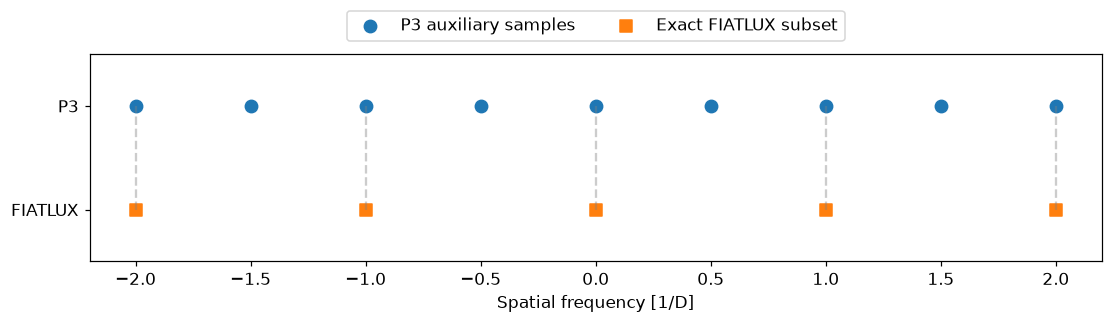

In [6]:
mono_overrides = copy.deepcopy(physical_overrides)
mono_overrides["sources_science"]["Wavelength"] = [1.1e-6]
mono = tiptop_psd(pupil_grid, config=config, overrides=mono_overrides, sampling_ratio=2)
assert mono.grid is pupil_grid
assert mono.diagnostics["sampling_ratio"] == 2
assert mono.power_nm2.shape == (1,N,N)
np.testing.assert_allclose(mono.p3_frequency_x[mono.indices_x], f.numpy(), atol=2e-10)
print("Pupil-only FIATLUX: N=",N,"df=",df,"cycles/m")
print("Auxiliary P3: nOtf=",mono.diagnostics["nOtf"],"df=",mono.diagnostics["PSDstep"],"cycles/m")
plt.rcdefaults()
plt.rcParams.update({"font.size":11,"axes.titlesize":12,"figure.dpi":110})
fig,ax=plt.subplots(figsize=(10,2.8),constrained_layout=True)
p3_units=mono.p3_frequency_x*D
sel=np.abs(p3_units)<2.1
ax.scatter(p3_units[sel],np.ones(sel.sum()),label="P3 auxiliary samples",s=65)
fiatlux_units=f.numpy()*D
sel=np.abs(fiatlux_units)<2.1
ax.scatter(fiatlux_units[sel],np.zeros(sel.sum()),label="Exact FIATLUX subset",marker="s",s=65)
for value in fiatlux_units[sel]:ax.plot([value,value],[0,1],"--",color="gray",alpha=.4)
ax.set(yticks=[0,1],yticklabels=["FIATLUX","P3"],xlabel="Spatial frequency [1/D]",ylim=(-.5,1.5))
ax.legend(loc="upper center",bbox_to_anchor=(.5,1.25),ncol=2)
plt.show()
assert pupil_grid.__dict__ == original_grid

## 6. The residual PSD

The dashed circle marks the P3 DM cutoff, not a sharp boundary between zero and nonzero residuals. Within it, imperfect correction leaves noise, aliasing and spatio-temporal errors; beyond it, fitting error remains. The plots show OPD density, not phase density or bin power.

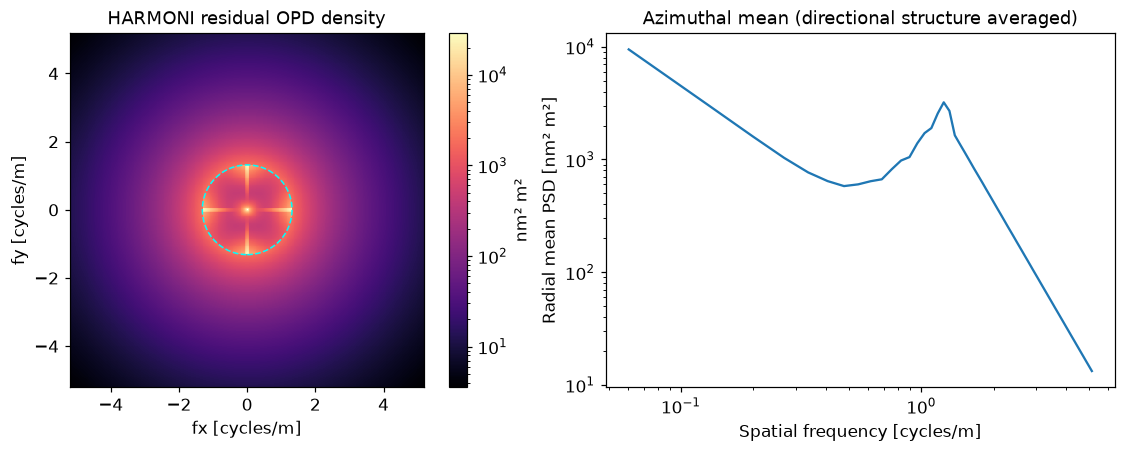

In [7]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "figure.dpi": 110})
density = torch.fft.fftshift(result.opd_psd[0]).cpu().numpy() * 1e18 # nm² m²
fx, fy = np.meshgrid(f.numpy(), f.numpy())
radius = np.hypot(fx, fy)
edges = np.linspace(df, f.max().item(), 75)
counts = np.histogram(radius, edges)[0]
def radial(values):
    return np.histogram(radius, edges, weights=values)[0] / np.maximum(counts, 1)
fmid = (edges[1:] + edges[:-1])/2
fig, axes = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
im = axes[0].pcolormesh(f.numpy(), f.numpy(), density, norm=LogNorm(), cmap="magma", shading="auto")
axes[0].add_patch(plt.Circle((0,0), result.diagnostics["ao_cutoff_cycles_per_m"], fill=False, color="cyan", linestyle="--"))
axes[0].set(xlabel="fx [cycles/m]", ylabel="fy [cycles/m]", title="HARMONI residual OPD density", aspect="equal")
fig.colorbar(im, ax=axes[0], label="nm² m²")
axes[1].loglog(fmid, radial(density))
axes[1].set(xlabel="Spatial frequency [cycles/m]", ylabel="Radial mean PSD [nm² m²]", title="Azimuthal mean (directional structure averaged)")
plt.show()

## 7. Components actually exposed by P3

P3 exposes fitting, noise, aliasing, **combined spatio-temporal** error, chromatism and differential refraction for this configuration. The combined term is not relabelled as pure servo lag or split into unexposed independent terms. The adapter applies the same bin-power multiplier as the total and embeds the AO-sized components at the same indices as P3. The sum is checked below; quadrature addition applies to these modeled PSD terms, not to arbitrary correlated error sources.

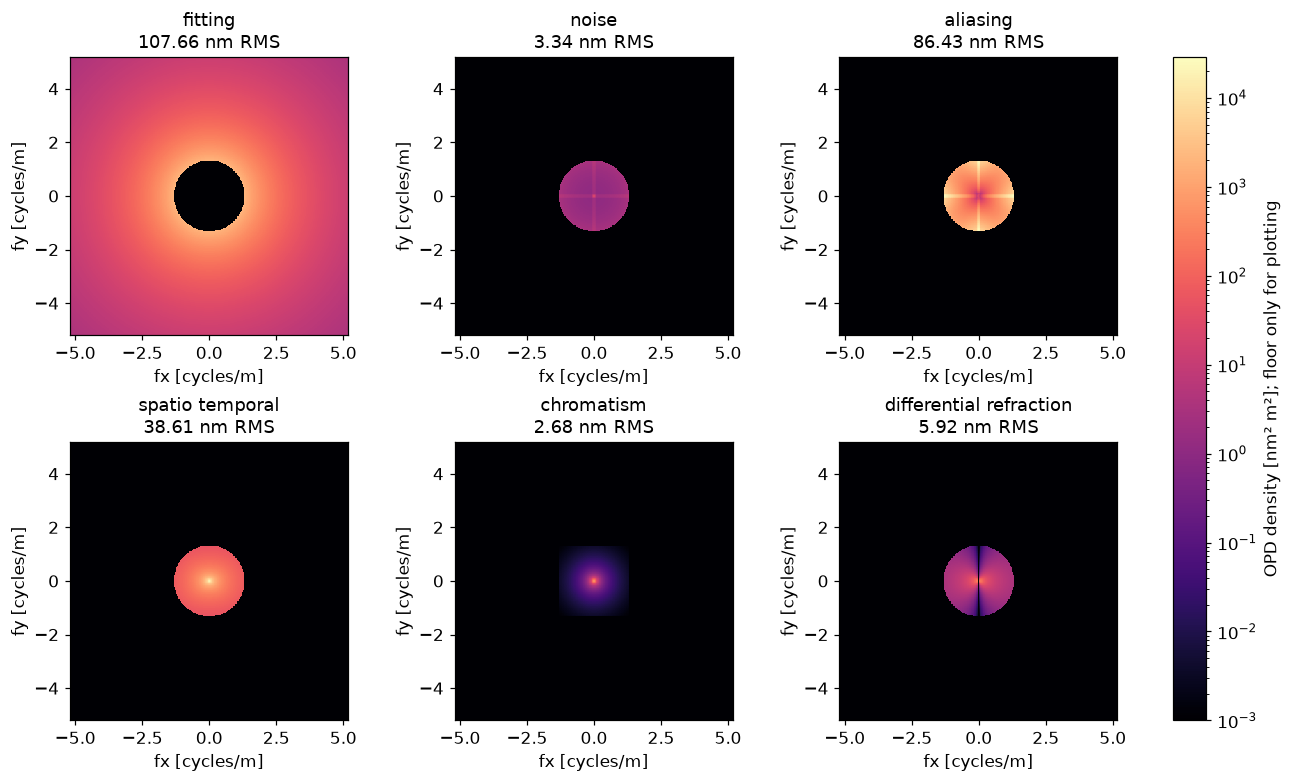

Component sum equals returned total: True


In [8]:
assert result.diagnostics["component_sum_matches_total"]
fig, axes = plt.subplots(2,3,figsize=(12,7),constrained_layout=True)
for ax, (name, power) in zip(axes.flat, result.components_nm2.items()):
    data = power[0].cpu().numpy()/df**2
    rms = float(power[0].sum().sqrt())
    im = ax.pcolormesh(f.numpy(), f.numpy(), np.maximum(data, 1e-6), norm=LogNorm(1e-3, max(1, density.max())), cmap="magma", shading="auto")
    ax.set(title=f"{name.replace(chr(95), chr(32))}\n{rms:.2f} nm RMS", xlabel="fx [cycles/m]", ylabel="fy [cycles/m]", aspect="equal")
fig.colorbar(im, ax=axes.ravel().tolist(), label="OPD density [nm² m²]; floor only for plotting")
plt.show()
print("Component sum equals returned total:", result.diagnostics["component_sum_matches_total"])

## 8. Integrated RMS and real-screen symmetry

Compute $\sigma_h=\sqrt{\sum W_h\Delta f^2}$ directly. No desired RMS is supplied anywhere.

A real stationary field requires $W(-f)=W(f)$. Finite P3 grids can be slightly asymmetric (including boundary effects). Screen generation rejects this unless symmetry averaging is **explicitly** requested. Averaging opposite bins changes the asymmetric part, preserves their sum, and is not interpolation or amplitude fitting. The exact selected raw P3 powers remain available in `result.selected_p3_power_nm2`; `result.power_nm2` contains density times the FIATLUX bin area. Symmetry averaging is an optional screen-generation step, separate from exact extraction; no 2×2 cells are averaged. DC is removed when drawing screens; here P3's DC is already zero. Pupil-weighted variance after piston removal is a different statistic from the full-grid ensemble variance validated here.

In [9]:
variance = result.opd_psd[0].sum() * df**2
rms_m = float(variance.sqrt())
model = result.atmosphere_model(symmetrize=True, seed=2026)
assert model.grid is pupil_grid
phase_to_opd = (model.reference_wavelength/(2*np.pi))**2
imported_variance = model.psd.sum() * df**2 * phase_to_opd
torch.testing.assert_close(imported_variance, variance, rtol=1e-12, atol=1e-27)
print(f"Integrated RMS = {rms_m:.9e} m = {rms_m*1e9:.3f} nm OPD")
print(f"Raw inversion asymmetry, L1 / total = {model.inversion_asymmetry:.4%}")
print("P3 normalization dk [cycles/m]:", result.diagnostics["p3_normalization_dk"])
print("Target df [cycles/m]:", df)
dk = result.diagnostics["p3_normalization_dk"]
selected_density = torch.fft.ifftshift(result.selected_p3_power_nm2[0]) * 1e-18 / dk**2
torch.testing.assert_close(result.opd_psd[0], selected_density, rtol=1e-12, atol=1e-30)
print("q = df_F / df_P:", result.diagnostics["sampling_ratio"])
print("P3 full-grid RMS is a different quadrature [nm]:", result.diagnostics["full_p3_rms_nm"])

Integrated RMS = 1.435451273e-07 m = 143.545 nm OPD
Raw inversion asymmetry, L1 / total = 0.7398%
P3 normalization dk [cycles/m]: 0.00865650969529086
Target df [cycles/m]: 0.025945721550516318
q = df_F / df_P: 3
P3 full-grid RMS is a different quadrature [nm]: [143.98781691494793]


## 9. Monte-Carlo screens and named Field dimensions

Filter real Gaussian noise using FIATLUX's existing PSD generator. Each realization has the same ensemble PSD but a different OPD map. We average **squared OPD / intensities**, not amplitudes. No physical cadence or frozen-flow claim is attached to the `realization` axis.

PSD RMS = 143.545 nm; Monte-Carlo RMS = 143.597 nm
Variance relative error = 0.073% (128 independent screens)


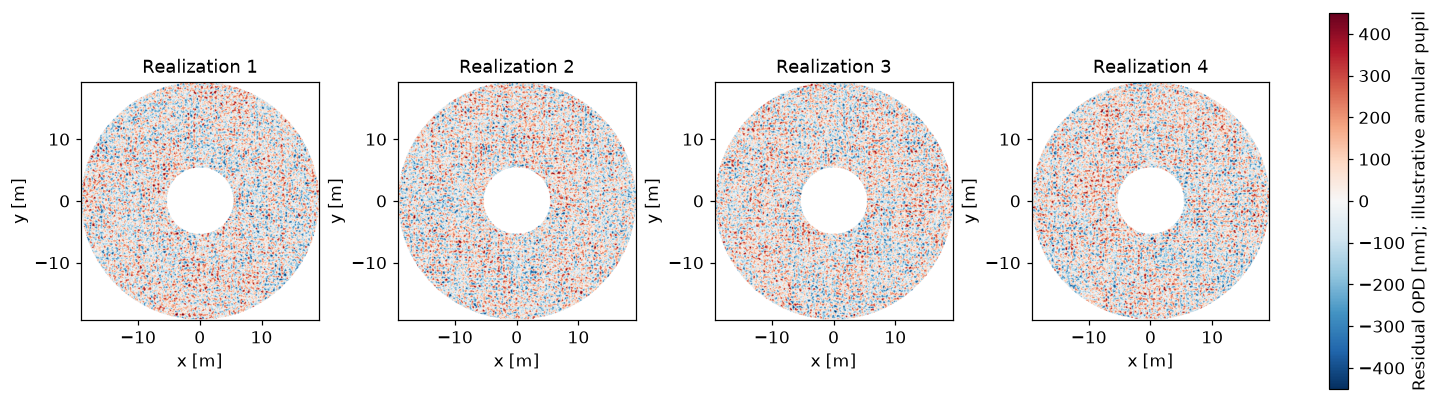

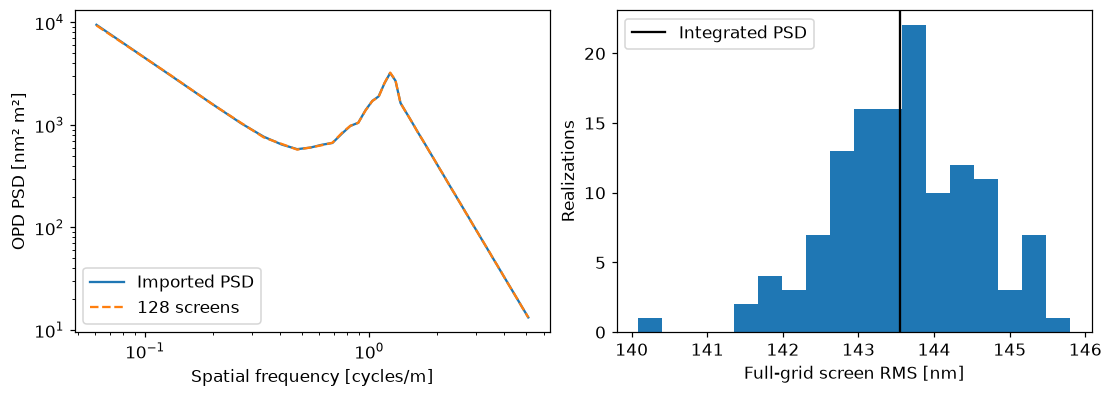

Field shape (realization, wavelength, y, x): (4, 3, 400, 400)


In [10]:
n_realizations = 128
variance_mc = 0.0
measured_power = torch.zeros(pupil_grid.shape, dtype=torch.float64)
rms_samples = []
for start in range(0, n_realizations, 8):
    screens = model.sample_opd_many(8)
    variance_mc += float(screens.square().sum()) / (n_realizations*N*N)
    measured_power += torch.fft.fft2(screens).abs().square().sum(0) / (n_realizations*(N*N)**2)
    rms_samples.extend((screens.square().mean((-2,-1)).sqrt()*1e9).tolist())
    if start == 0:
        examples = screens[:4].clone()
error = variance_mc / float(variance) - 1
assert abs(error) < .03
print(f"PSD RMS = {rms_m*1e9:.3f} nm; Monte-Carlo RMS = {np.sqrt(variance_mc)*1e9:.3f} nm")
print(f"Variance relative error = {error:.3%} ({n_realizations} independent screens)")
x,y = pupil_grid.meshgrid()
pupil = ((x*x+y*y < (D/2)**2) & (x*x+y*y > (.28*D/2)**2))
fig, axes = plt.subplots(1,4,figsize=(13,3.5),constrained_layout=True)
for i,ax in enumerate(axes):
    data = np.ma.masked_where(~pupil.numpy(), examples[i].numpy()*1e9)
    im=ax.imshow(data,origin="lower",extent=[-L/2,L/2,-L/2,L/2],cmap="RdBu_r",vmin=-450,vmax=450)
    ax.set(title=f"Realization {i+1}",xlabel="x [m]",ylabel="y [m]")
fig.colorbar(im,ax=axes,label="Residual OPD [nm]; illustrative annular pupil")
plt.show()
fig,axes=plt.subplots(1,2,figsize=(10,3.5),constrained_layout=True)
measured_density=torch.fft.fftshift(measured_power).numpy()/df**2*1e18
symmetric_density=torch.fft.fftshift(model.psd).numpy()*phase_to_opd*1e18
axes[0].loglog(fmid,radial(symmetric_density),label="Imported PSD")
axes[0].loglog(fmid,radial(measured_density),"--",label="128 screens")
axes[0].set(xlabel="Spatial frequency [cycles/m]",ylabel="OPD PSD [nm² m²]");axes[0].legend()
axes[1].hist(rms_samples,bins=18)
axes[1].axvline(rms_m*1e9,color="black",label="Integrated PSD")
axes[1].set(xlabel="Full-grid screen RMS [nm]",ylabel="Realizations");axes[1].legend()
plt.show()
# Apply the same physical OPD to every science wavelength.
amplitude = pupil.to(torch.complex128).expand(3,N,N).clone()
field = Field(amplitude, pupil_grid, spectrum)
cube = field.apply_opd(examples, dimensions=(FieldDimension("realization",4),))
assert cube.complex_amplitude.shape == (4,3,N,N)
assert cube.grid is pupil_grid
assert pupil_grid.__dict__ == original_grid
print("Field shape (realization, wavelength, y, x):",tuple(cube.complex_amplitude.shape))

## 10. Common sampling mistakes

| Mistake | What to check |
|---|---|
| Same shape, different frequency step | Verify `PSDstep` and actual coordinates, not only `nOtf`. |
| Same diameter, different padding | Derive extent from `Grid.nx * Grid.dx`, never from diameter alone. |
| Resize FIATLUX to suit TIPTOP | Keep the simulation unchanged; configure a sufficiently fine and large P3 auxiliary grid. |
| Interpolate a PSD | Reject incompatible increments; only exact coordinate subsets are allowed, including integer-stride extraction. |
| Forget `fftshift` | P3 outputs centered bin powers; FIATLUX stores native FFT order. |
| Confuse OPD and phase | Use the wavelength-squared conversion with explicit units. |
| Omit the bin area | Density integration requires `df**2`; bin power already includes integration. |
| Force a requested RMS | Preserve physical P3 power; compare Monte-Carlo statistics instead. |
| Set only `FieldOfView` | Also inspect wavelength-dependent `k_`, `kRef_`, `PSDstep`, `kx_`, `ky_`. |
| Interpret screens as a time series | A spatial residual PSD does not determine temporal correlations. |

**Limits:** square isotropic grids and single-NGS SCAO; normalization verified against P3 1.6.2; static OPD is separate; default WFS flux is the preset value until a guide-star calibration is supplied. The standard P3 evaluator supplies the auxiliary grid; FIATLUX remains unchanged. Third-party P3 may interpolate static pupil/OTF inputs internally; the residual PSD extraction never calls interpolation. The tutorial does not claim validation of a complete HARMONI instrument model.